# Discretizare

O problema metodologica serioasa:


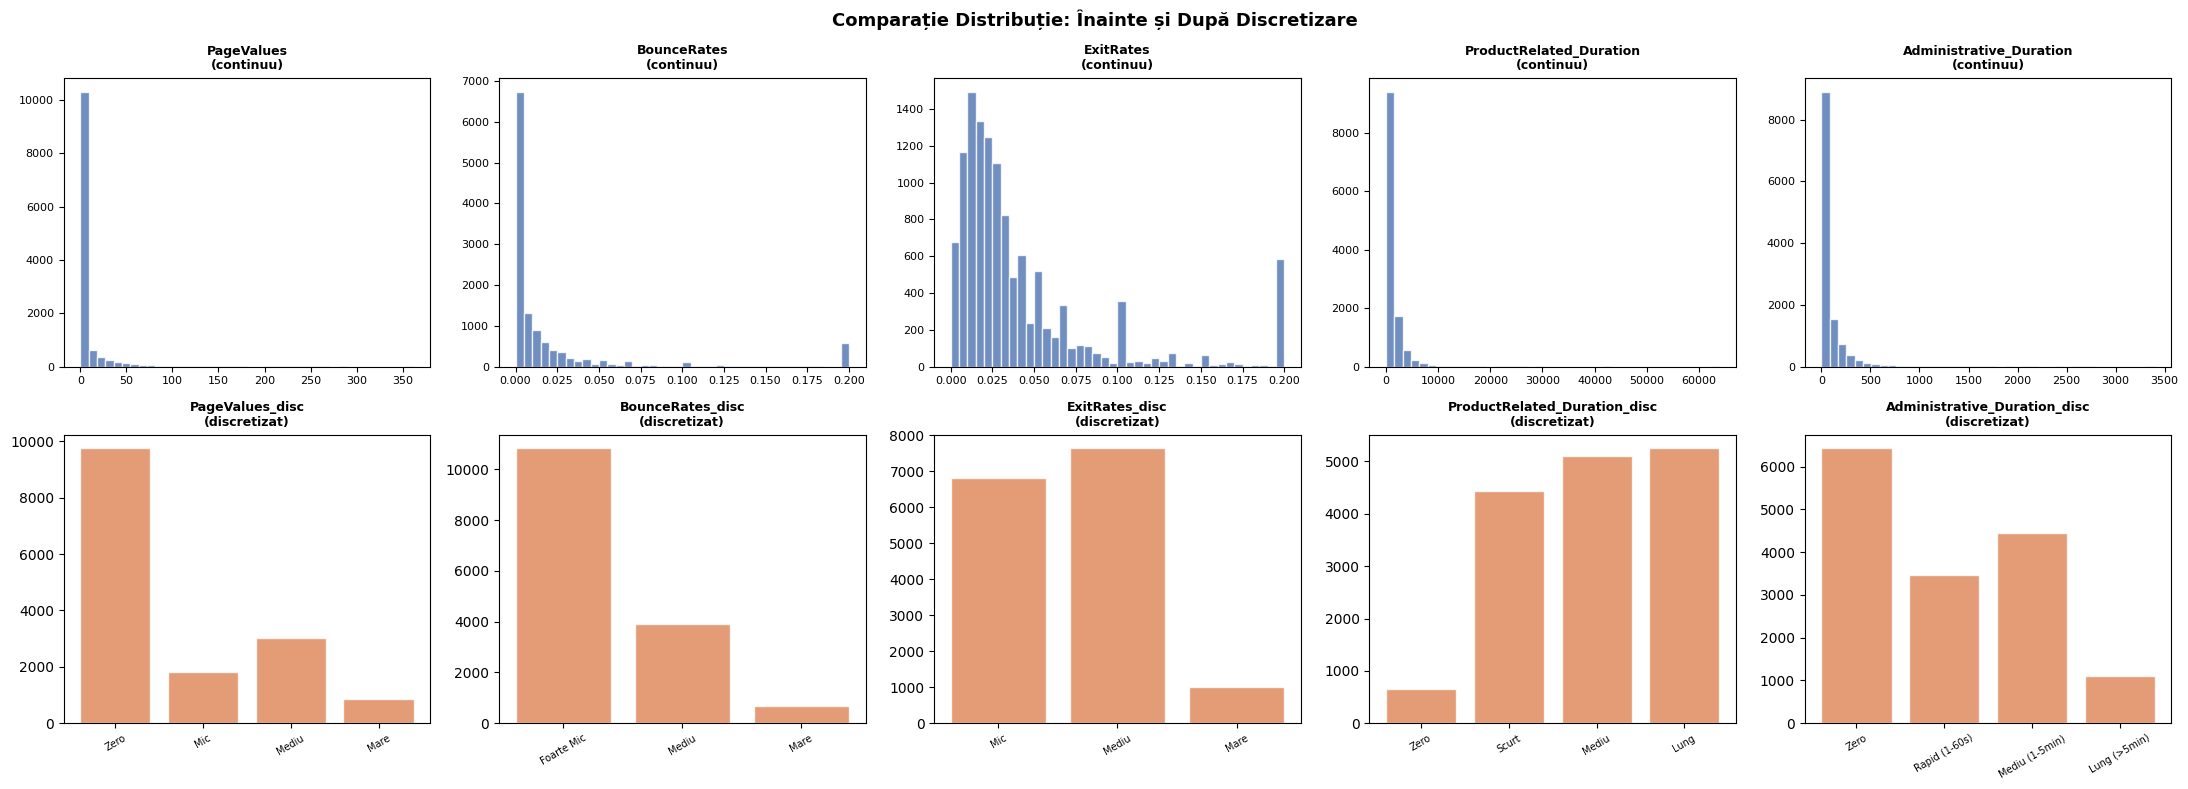

-   Daca folosesc quantilele impun trecerea de la o distributie specifica la o distributie uniforma. Asta va afecta semnificativ legaturile cu variabila obiectiv. Dupa cum putem observa avem cateva variabile cu foarte multe valori de 0 sau foarte apropiate de 0

-   Am putea face o grupare pe intervale egale, deschise pentru ultimul interval pentru a absorbi valorile extreme. Pe un numar de intervale impar (5) care sa permita si o variabilitate decenta 

### Problema reala

BounceRates discretizat:

-   Foarte Mic: 10k obs

-   Mediu: 4k obs

-   Mare: 600 obs

68% din date aprox sunt la foarte mic, si ce ?

-   Am creat o distributie si mai dezechilibrata decat originalul. Categoria Foarte Mic inghite tot si nu mai discrimineaza nimic util pentru arbore

### Sa trecem la treaba

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
path_to_dataset = '../../data/raw/online_shoppers_intention_recoded.csv'

if not os.path.isfile(path_to_dataset):
    print("no good")
else:
    df = pd.read_csv(path_to_dataset)

In [3]:
df.shape

(12330, 18)

In [4]:
df.duplicated().sum()

np.int64(125)

In [5]:
df = df.drop_duplicates()
df.shape[0]

12205

In [7]:
df_final = df.copy()

BounceRates: 45.2% zerouri → flag creat
PageValues: 77.6% zerouri → flag creat
Administrative_Duration: 47.3% zerouri → flag creat
Informational_Duration: 80.3% zerouri → flag creat
ProductRelated_Duration: 5.2% zerouri → flag creat
DISCRETIZARE CU INTERVALE EGALE (5 intervale + Zero)

  BounceRates:
  Step: 0.0400
    Interval 1: [0.0000, 0.0400) → mijloc: 0.02
    Interval 2: [0.0400, 0.0800) → mijloc: 0.06
    Interval 3: [0.0800, 0.1200) → mijloc: 0.1
    Interval 4: [0.1200, 0.1600) → mijloc: 0.14
    Interval 5: [0.1600, ∞) → mijloc: 0.18

  PageValues:
  Step: 16.2372
    Interval 1: [0.0380, 16.2752) → mijloc: 8.1566
    Interval 2: [16.2752, 32.5124) → mijloc: 24.3938
    Interval 3: [32.5124, 48.7496) → mijloc: 40.631
    Interval 4: [48.7496, 64.9868) → mijloc: 56.8682
    Interval 5: [64.9868, ∞) → mijloc: 73.1054

  ProductRelated_Duration:
  Step: 885.6880
    Interval 1: [0.5000, 886.1880) → mijloc: 443.344
    Interval 2: [886.1880, 1771.8760) → mijloc: 1329.032
    Int

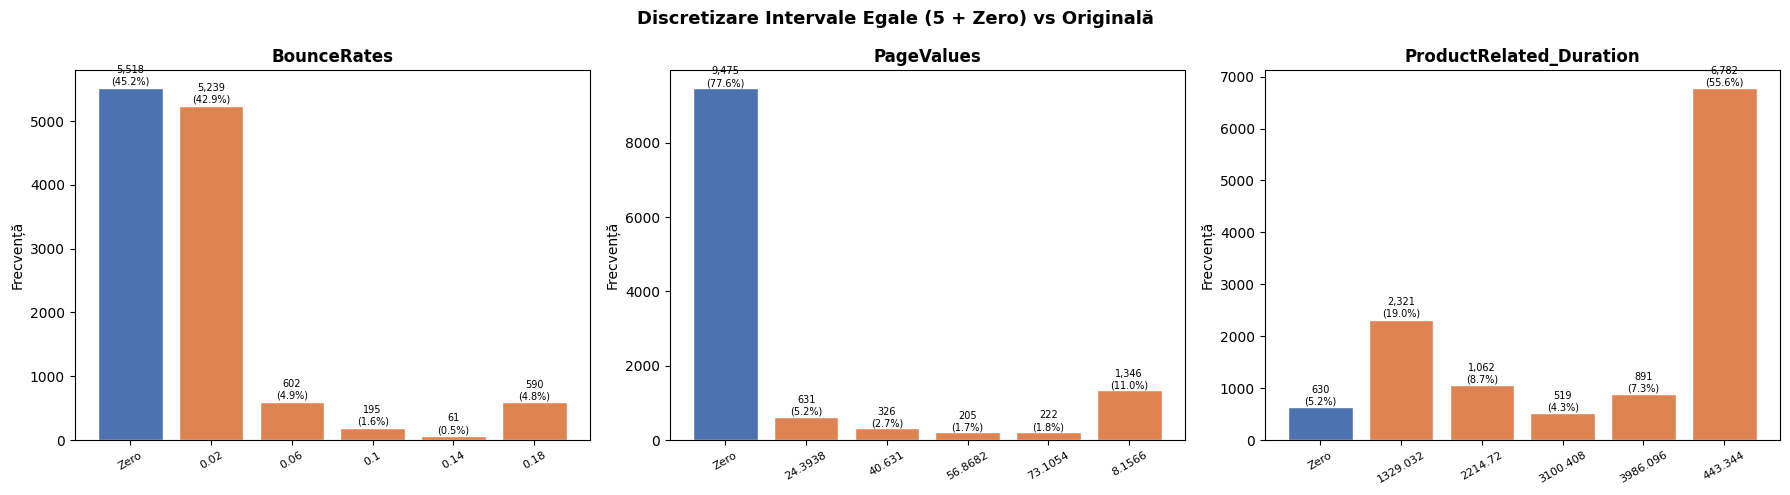


VERIFICARE LEGĂTURĂ CU REVENUE (rata conversie per interval)

  BounceRates_disc2:
    0.02         →  16.1% conversie  ████████
    0.06         →   3.5% conversie  █
    0.1          →   1.5% conversie  
    0.14         →   0.0% conversie  
    0.18         →   0.5% conversie  
    Zero         →  18.8% conversie  █████████

  PageValues_disc2:
    24.3938      →  60.4% conversie  ██████████████████████████████
    40.631       →  73.0% conversie  ████████████████████████████████████
    56.8682      →  80.5% conversie  ████████████████████████████████████████
    73.1054      →  81.5% conversie  ████████████████████████████████████████
    8.1566       →  42.6% conversie  █████████████████████
    Zero         →   3.9% conversie  █

  ProductRelated_Duration_disc2:
    1329.032     →  20.7% conversie  ██████████
    2214.72      →  22.2% conversie  ███████████
    3100.408     →  22.2% conversie  ███████████
    3986.096     →  30.9% conversie  ███████████████
    443.344      →  

In [8]:
# ─────────────────────────────────────
# PASUL 1: Izolezi zero-urile ca flag
# ─────────────────────────────────────
cols_zero_inflation = [
    'BounceRates', 'PageValues',
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration'
]

for col in cols_zero_inflation:
    pct = (df_final[col] == 0).mean() * 100
    df_final[f'{col}_isZero'] = (df_final[col] == 0).astype(int)
    print(f"{col}: {pct:.1f}% zerouri → flag creat")

# ─────────────────────────────────────
# PASUL 2: Intervale egale DOAR pe non-zero
# cu ultimul interval deschis (absorb extreme)
# ─────────────────────────────────────

def discretize_nonzero(series, n_intervals=5, col_name=''):
    """
    - Zero → categorie separată 'Zero'
    - Non-zero → n intervale egale pe domeniul non-zero
    - Ultimul interval deschis → absoarbe outlierii
    - Codificare cu mijlocul intervalului
    """
    result   = pd.Series(['Zero'] * len(series), index=series.index, dtype=object)
    nonzero  = series[series > 0]

    if len(nonzero) == 0:
        return result

    min_val = nonzero.min()
    max_val = nonzero.quantile(0.95)  # 95th percentile ca limită superioară
                                       # restul 5% absorbite în ultimul interval

    step  = (max_val - min_val) / n_intervals
    edges = [min_val + i * step for i in range(n_intervals)]
    edges.append(float('inf'))  # ultimul interval deschis → absoarbe extreme

    # Mijloacele intervalelor pentru codificare
    midpoints = []
    for i in range(len(edges) - 1):
        if edges[i+1] == float('inf'):
            mid = edges[i] + step / 2  # estimare pentru intervalul deschis
        else:
            mid = (edges[i] + edges[i+1]) / 2
        midpoints.append(round(mid, 4))

    print(f"\n  {col_name}:")
    print(f"  Step: {step:.4f}")
    for i in range(len(edges)-1):
        label = f"[{edges[i]:.4f}, {'∞' if edges[i+1]==float('inf') else f'{edges[i+1]:.4f}'})"
        print(f"    Interval {i+1}: {label} → mijloc: {midpoints[i]}")

    # Aplicare pe non-zero
    for idx in nonzero.index:
        val = series[idx]
        for i in range(len(edges) - 1):
            if edges[i] <= val < edges[i+1] or (edges[i+1] == float('inf') and val >= edges[i]):
                result[idx] = str(midpoints[i])
                break

    return result

# ─────────────────────────────────────
# PASUL 3: Aplicare cu 5 intervale
# ─────────────────────────────────────

print("=" * 60)
print("DISCRETIZARE CU INTERVALE EGALE (5 intervale + Zero)")
print("=" * 60)

df_final['BounceRates_disc2'] = discretize_nonzero(
    df_final['BounceRates'], n_intervals=5, col_name='BounceRates')

df_final['PageValues_disc2'] = discretize_nonzero(
    df_final['PageValues'], n_intervals=5, col_name='PageValues')

df_final['ProductRelated_Duration_disc2'] = discretize_nonzero(
    df_final['ProductRelated_Duration'], n_intervals=5,
    col_name='ProductRelated_Duration')

# ─────────────────────────────────────
# PASUL 4: Verificare distribuție rezultată
# ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Discretizare Intervale Egale (5 + Zero) vs Originală',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['BounceRates', 'PageValues', 'ProductRelated_Duration']):
    disc_col = f'{col}_disc2'
    vc = df_final[disc_col].value_counts()

    # Sortare: Zero primul, restul numeric
    zero_count = vc.get('Zero', 0)
    rest = vc.drop('Zero', errors='ignore').sort_index()

    labels = ['Zero'] + rest.index.tolist()
    values = [zero_count] + rest.values.tolist()

    colors = ['#4C72B0'] + ['#DD8452'] * len(rest)
    ax.bar(range(len(labels)), values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, fontsize=8)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecvență')

    for i, v in enumerate(values):
        ax.text(i, v + 50, f'{v:,}\n({v/len(df_final)*100:.1f}%)',
                ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('../../outputs/discretizare_intervale_egale.png', dpi=150)
plt.show()

# ─────────────────────────────────────
# PASUL 5: Verificare păstrare legături cu Revenue
# ─────────────────────────────────────

print("\n" + "=" * 60)
print("VERIFICARE LEGĂTURĂ CU REVENUE (rata conversie per interval)")
print("=" * 60)

for col in ['BounceRates_disc2', 'PageValues_disc2', 'ProductRelated_Duration_disc2']:
    print(f"\n  {col}:")
    conv = df_final.groupby(col)['Revenue'].mean().sort_index() * 100
    for cat, rate in conv.items():
        bar = '█' * int(rate / 2)
        print(f"    {str(cat):<12} → {rate:>5.1f}% conversie  {bar}")

In [9]:
# Verifică corelația între flaguri
flag_cols = [c for c in df_final.columns if '_isZero' in c]
corr = df_final[flag_cols].corr()
print(corr.round(2))

                                BounceRates_isZero  PageValues_isZero  \
BounceRates_isZero                            1.00               0.02   
PageValues_isZero                             0.02               1.00   
Administrative_Duration_isZero               -0.03               0.30   
Informational_Duration_isZero                 0.13               0.24   
ProductRelated_Duration_isZero               -0.18               0.13   

                                Administrative_Duration_isZero  \
BounceRates_isZero                                       -0.03   
PageValues_isZero                                         0.30   
Administrative_Duration_isZero                            1.00   
Informational_Duration_isZero                             0.30   
ProductRelated_Duration_isZero                            0.22   

                                Informational_Duration_isZero  \
BounceRates_isZero                                       0.13   
PageValues_isZero                 

-   "Intervale egale vs quartile?" -> Intervale egale sunt superioare când am zero-inflation. Quartilele distorsionează tocmai zona de interes (valorile mici non-zero)

-   "Număr impar, 5 sau 7?" -> 5 intervale e optim pentru datele mele. Cu 7 riscă unele intervale să aibă prea puține observații după izolarea zero-urilor

-   "Codificare cu mijlocul intervalului?" -> păstrează ordinea și distanțele relative, mai bună decât label-uri ordinale arbitrare

-   "Izolarea zero-urilor?" -> Da, obligatoriu: zero înseamnă ceva complet diferit față de 0.001. Semantic sunt categorii distincte

-   "Flag binar ca meta-analiză?" -> în plus față de discretizare, nu în loc de ea.

### Inca o posibila problema

-   Ce se intampla daca am colinearitate perfecta intre flaguri ? Adica de fiecare data cand unul e 0, celelalte sunt tot 0. Daca gasesc corelatii > 0.8 intre flaguri am redundanta si trebuie eliminat unul

-   Daca nu sunt corelate atunci e foarte bine, pentru ca contribuim la un profil comportamental real si distinct al unui user

ProductRelated_Duration = 0  -> n-a stat deloc pe pagini de produse

BounceRates = 0              -> n-a bounced deloc (a navigat activ)

PageValues = 0               ->  n-a vizitat pagini cu valoare comercială

Administrative_Duration = 0  -> n-a vizitat pagini administrative